<a href="https://colab.research.google.com/github/Raajarapu/COLAB_practice/blob/main/FNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Below is an extensive overview of Feedforward Neural Networks (FNNs)

---

## 1. Purpose

The primary purpose of Feedforward Neural Networks is to learn and represent complex, non-linear relationships between inputs and outputs. They are engineered to approximate any continuous function, making them suitable for an array of tasks—ranging from classification and regression to function approximation. In essence, FNNs serve as a fundamental building block for numerous applications in artificial intelligence and pattern recognition.

---

## 2. Definition

A Feedforward Neural Network is a type of artificial neural network wherein the connections between the nodes do not form cycles. In other words, data flows unidirectionally—from the input layer, through one or more hidden layers, and ultimately to the output layer. There are typically three distinct phases within an FNN:

1. **Input Phase:** The raw data is introduced to the network via the input layer.
2. **Processing Phase (Forward Propagation):** Data is transmitted through hidden layers. Each neuron in these layers computes a weighted sum of its inputs, adds a bias, and applies an activation function to produce an output.
3. **Output Phase:** The network produces its final prediction or classification based on the transformed data from the hidden layers.

Training, which involves backpropagation and weight adjustment, is a crucial operational phase although it is not part of the forward calculation itself.

---

## 3. Formula

At the heart of an FNN is the mathematical operation performed by each neuron. The fundamental computation can be expressed by the following formula:

\[
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
\]

Where:  
- \(x_i\) are the input features.  
- \(w_i\) represent the weights associated with each input.  
- \(b\) is the bias term.  
- \(f\) denotes the activation function (such as ReLU, sigmoid, or softmax).  

This computation is performed for every neuron in the hidden layers, and for multiple layers the process can be viewed as a nested composition of such functions:

\[
y = f_n\Big(W_n \, f_{n-1}\Big( \dots f_1\big(W_1 x + b_1\big) \dots \Big) + b_n\Big)
\]

---

## 4. Detailed Explanation of Operations

In practical terms, the operations of a Feedforward Neural Network proceed as follows:

1. **Input Reception:** The network receives raw input data at the input layer. For example, in image recognition, each pixel value might be an input.
2. **Forward Propagation:**  
   - **Weighted Sum:** In each neuron, every input value is multiplied by a specific weight.  
   - **Bias Addition:** A bias is added to the weighted sum to shift the activation function’s output.  
   - **Activation Function:** This linear combination then passes through a non-linear activation function (e.g., ReLU) to capture non-linear patterns.  
   - **Layer-by-Layer Processing:** This procedure repeats as the data moves through successive hidden layers, thereby forming increasingly abstract representations.
3. **Output Generation:** Finally, the processed data reaches the output layer, where a decision or prediction is made. In classification tasks, the softmax activation is frequently employed to produce probability distributions over classes.
4. **Learning Through Training:** Although not part of the forward pass, the network undergoes training using backpropagation. Errors (derived from a loss function) are propagated backward, enabling the network to optimally adjust its weights and biases.

---

## 5. Advantages

- **Simplicity:** FNNs are conceptually straightforward and relatively easy to implement, lending themselves well to educational purposes and rapid prototyping.
- **Universal Approximation:** They possess the remarkable ability to approximate any continuous function given sufficient neurons and proper training, as stated by the universal approximation theorem.
- **Speed in Inference:** The absence of cycles ensures that the inference process is efficient and direct.
- **Versatile Applications:** Their general architecture makes them well-suited for a wide range of tasks, from basic pattern recognition to more elaborate predictive modelling.

---

## 6. Disadvantages

- **Limited Memory:** FNNs are inherently incapable of handling sequential or time-dependent data effectively, as they lack memory units.
- **Local Minima:** The optimisation process through gradient descent may lead to convergence at local minima rather than the global minimum.
- **Data Dependency:** They often require substantial amounts of training data to perform effectively, particularly when dealing with deep architectures.
- **Overfitting Risks:** Without adequate regularisation or sufficient data, FNNs are prone to overfitting—where the model performs well on training data but poorly on unseen data.

---

## 7. Limitations

- **Temporal Dynamics:** Due to a lack of recurrent connections, FNNs do not naturally account for temporal or sequential dependencies.
- **Scalability Issues:** As the network depth increases, challenges such as increased computational cost and potential vanishing gradients may arise.
- **Static Architecture:** Once designed, the architecture of an FNN cannot dynamically adapt to varying patterns of data as effectively as some other neural network architectures (e.g., Convolutional Neural Networks for spatial data or Recurrent Neural Networks for sequence data).
- **Hyperparameter Sensitivity:** Their performance is sensitive to the choice of hyperparameters, such as learning rate, number of layers, and neuron counts, necessitating thorough experimentation.

---

## 8. Applications

Feedforward Neural Networks are widely applied in diverse areas. Some notable applications include:

- **Classification Tasks:** Such as digit recognition (e.g., the MNIST dataset), spam detection, or medical diagnosis.
- **Regression Analyses:** For tasks like forecasting economic indicators, predicting stock prices, or estimating house values.
- **Function Approximation:** In control systems where modelling and approximating dynamic systems are required.
- **Distinction from Other Models:**  
  - Compared to *Convolutional Neural Networks (CNNs)*, which excel in spatial data processing (like image analysis), FNNs are typically used for non-structured, vector-based data.  
  - Unlike *Recurrent Neural Networks (RNNs)* that are designed to handle sequential and time-series data, FNNs are more appropriate for static datasets where the temporal context is irrelevant.

---

## 9. Code Example with Clear Comments

Below is a well-commented Python code example demonstrating a simple Feedforward Neural Network using TensorFlow/Keras on the MNIST dataset:

```python
# Import necessary libraries for building and training the model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Step 1: Load the MNIST dataset, which consists of 28x28 grayscale images of handwritten digits.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the pixel values to the range [0, 1] to facilitate faster and more stable training.
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert the integer labels into a one-hot encoded format for multi-class classification.
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Step 2: Build the Feedforward Neural Network model using TensorFlow's Keras API.
model = Sequential([
    # The Flatten layer transforms the 2D 28x28 images into a 1D array of 784 pixels.
    Flatten(input_shape=(28, 28)),
    
    # A Dense (fully connected) layer with 128 neurons and the ReLU activation function to introduce non-linearity.
    Dense(128, activation='relu'),
    
    # An additional Dense hidden layer with 64 neurons, also using the ReLU activation function.
    Dense(64, activation='relu'),
    
    # The output layer consists of 10 neurons corresponding to the 10 digit classes.
    # The softmax activation function is used to generate a probability distribution over the classes.
    Dense(10, activation='softmax')
])

# Step 3: Compile the model.
# - 'adam' is an efficient optimizer that adapts the learning rate during training.
# - 'categorical_crossentropy' is a loss function suitable for multi-class classification tasks.
# - 'accuracy' is used as a metric to monitor the model's performance.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display a summary of the model architecture, including layer details and number of parameters.
model.summary()

# Step 4: Train the model on the training data.
# - 'epochs' defines the number of complete passes through the training dataset.
# - 'batch_size' specifies the number of samples to work through before updating the internal model parameters.
# - 'validation_split' reserves a fraction of the training data to evaluate the model's performance during training.
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Step 5: Evaluate the model on the test dataset to determine its generalisation capability.
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")
```

---


In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 627.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.3 MB/s eta 0:00:00


## 1. Importing Libraries


- Purpose:
These import statements load the necessary libraries and modules from TensorFlow and Keras.
- Operation:- tensorflow as tf: Grants access to the TensorFlow package.
- Sequential: Enables you to build a model layer by layer.
- Dense and Flatten: These layers define fully connected layers and the operation to convert multi-dimensional data into a one-dimensional array, respectively.
- mnist: Imports the MNIST dataset, a classic dataset for handwritten digit recognition.
- to_categorical: Provides a convenient method to convert integer labels into a one-hot encoded format.




In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## 2. Loading the MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


- Purpose:
Load the training and testing sets from the MNIST dataset.
- Operation:
The function returns two tuples:- (x_train, y_train): Contains 60,000 grayscale images (each 28×28 pixels) and their corresponding digit labels (0–9).
- (x_test, y_test): Contains 10,000 images reserved for evaluating the model’s performance.





In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 3. Normalizing Pixel Values


x_train = x_train / 255.0
x_test = x_test / 255.0


- Purpose:
To normalize the data so that the pixel intensity values fall within the interval [0, 1].
- Operation:
Each pixel in an image is divided by 255 (the maximum possible pixel value) transforming integer values into floating-point numbers. This normalization is critical; it accelerates the convergence of the learning algorithm and helps maintain numerical stability.

Example:
A pixel value of 128 becomes approximately 0.502.


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## 4. Converting Labels to One-Hot Encoding


y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


- Purpose:
Transform the integer labels into a one-hot encoded format suitable for categorical classification tasks.
- Operation:
For each label (e.g., 3), to_categorical converts it to a vector of length 10 with zeros everywhere except a one at the index corresponding to the digit.
- Result:
The label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].
This encoding is necessary because the loss function, categorical_crossentropy, compares probability distributions.





In [ ]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

## 5. Building the Feedforward Neural Network Model


model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])




- Purpose:
Define the architecture of the neural network.
- Operation:- Flatten Layer:- Operation: Converts each 28×28 image into a 1D vector of 784 elements.
- Rationale: Most Dense layers require one-dimensional input.

- First Dense Layer (128 neurons):- Operation: Computes a weighted sum of inputs, adds a bias, and applies the ReLU activation function, introducing non-linearity.

- Second Dense Layer (64 neurons):- Operation: Similar to the first Dense layer but with fewer neurons; this helps the network learn hierarchical representations.

- Output Dense Layer (10 neurons):- Operation: Computes the final class scores for the 10 possible classes; the softmax activation ensures that the output is a probability distribution.






In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 6. Compiling the Model


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
              


- Purpose:
Prepare the model for training by specifying the optimizer, loss function, and evaluation metrics.
- Operation:- Optimizer (Adam):- Implements an adaptive learning rate algorithm that combines the benefits of two other popular methods (AdaGrad and RMSProp).

- Loss Function (Categorical Crossentropy):- Measures the dissimilarity between the predicted probability distribution and the actual distribution (one-hot encoded labels).

- Metric (Accuracy):- Allows for monitoring the proportion of correctly predicted labels during training and evaluation.







In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## 7. Displaying the Model Architecture

model.summary()



- Purpose:
Print a summary of the model architecture including layers, output shapes, and the number of parameters in each layer.
- Operation:
The summary informs you about:- The input and output dimensions at each layer.
- The total number of learnable parameters, providing insight into the model’s complexity.


Expected Output:
A table-like display listing each layer (Flatten, Dense, Dense, Dense) with associated parameter counts, invaluable for debugging and model optimization.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Training the Model

model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)




- Purpose:
Train the neural network using the training dataset.
- Operation:- Epochs:- The model goes through the entire dataset 5 times.

- Batch Size:- The training data is divided into smaller chunks (batches of 32 samples), and the weights are updated after each batch.

- Validation Split:- 10% of the training data is set aside for validation. This helps monitor the model’s performance on unseen data at each epoch.


- Process:
During each epoch, the model:- Performs a forward pass (computing predicted outputs).
- Computes the loss via the loss function.
- Executes a backward pass (backpropagation) where errors are propagated back to update weights.

- Outcome:
The model’s training and validation accuracy and loss are printed after each epoch. You observe gradually improving accuracy and diminishing loss if the model is learning effectively.




In [ ]:
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8685 - loss: 0.4616 - val_accuracy: 0.9647 - val_loss: 0.1159
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9656 - loss: 0.1143 - val_accuracy: 0.9703 - val_loss: 0.1036
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9766 - loss: 0.0730 - val_accuracy: 0.9732 - val_loss: 0.0895
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0528 - val_accuracy: 0.9787 - val_loss: 0.0787
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.9773 - val_loss: 0.0832


## 9. Evaluating the Model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


- Purpose:
Assess the model’s performance on the test dataset, which was not used during training.
- Operation:- model.evaluate: Computes the loss and accuracy on the test data.
- Printing the result reveals the overall generalisation capability of the neural network.


Expected Outcome:
A printed statement similar to:
Test Accuracy: 0.97




In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9712 - loss: 0.0957
Test Accuracy: 0.98


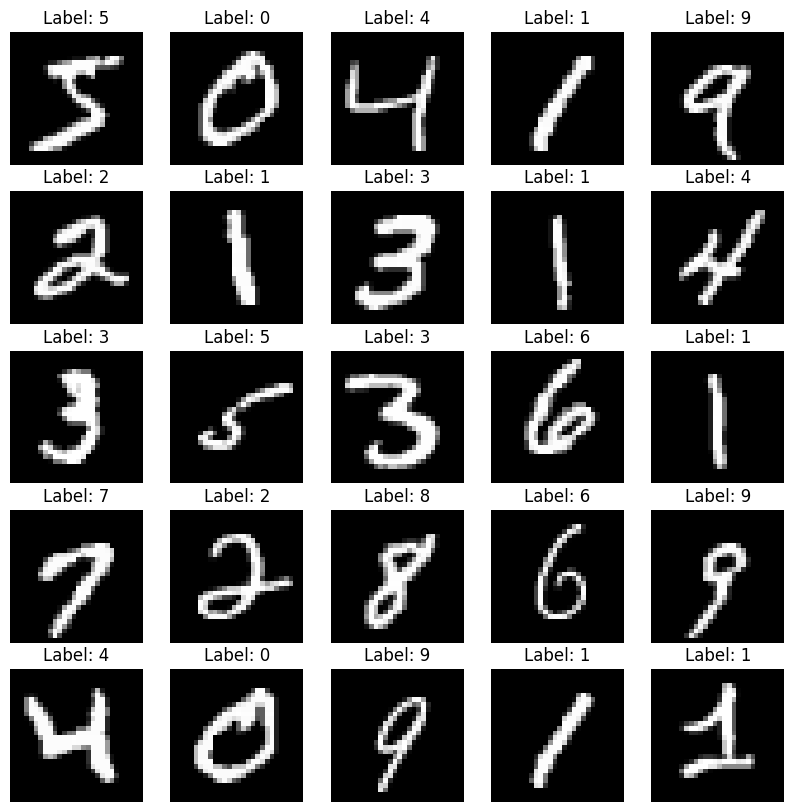

In [12]:
# Import the necessary libraries for visualization
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images: pixel values are scaled between 0 and 1.
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode the labels (note: for visualization, we often use the original labels).
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Set up the figure: a grid of 5 rows and 5 columns
plt.figure(figsize=(10, 10))  # Set figure size for clarity

# Display the first 25 images from the training set in the grid.
for i in range(25):
    # Create a subplot in a 5x5 grid
    plt.subplot(5, 5, i + 1)

    # Display the image in grayscale
    plt.imshow(x_train[i], cmap='gray')

    # Retrieve and display the label as the image title
    # 'y_train' contains the digit labels (e.g., 0, 1, 2, ...)
    plt.title(f"Label: {y_train[i]}")

    # Remove axes for better visualization
    plt.axis('off')

# Finally, show the complete plot with all the images
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


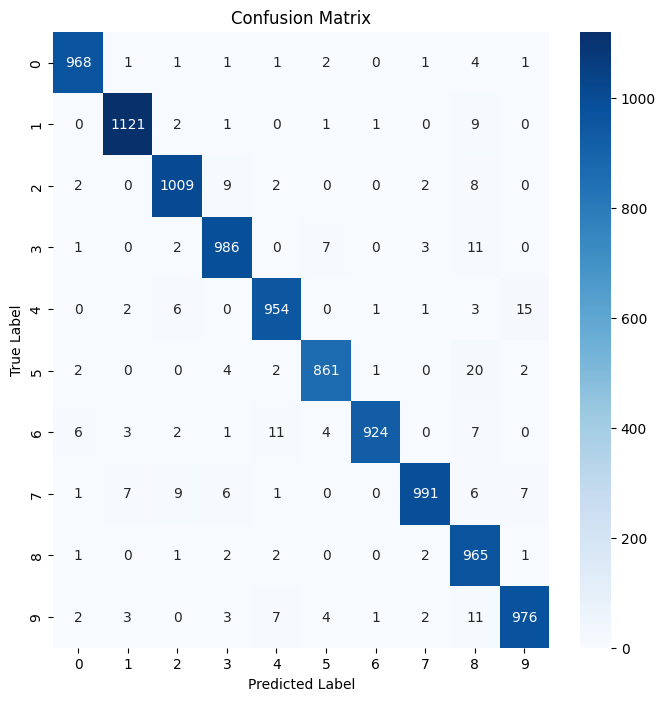

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate predictions from the test dataset
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Visualize the confusion matrix using a heatmap from seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

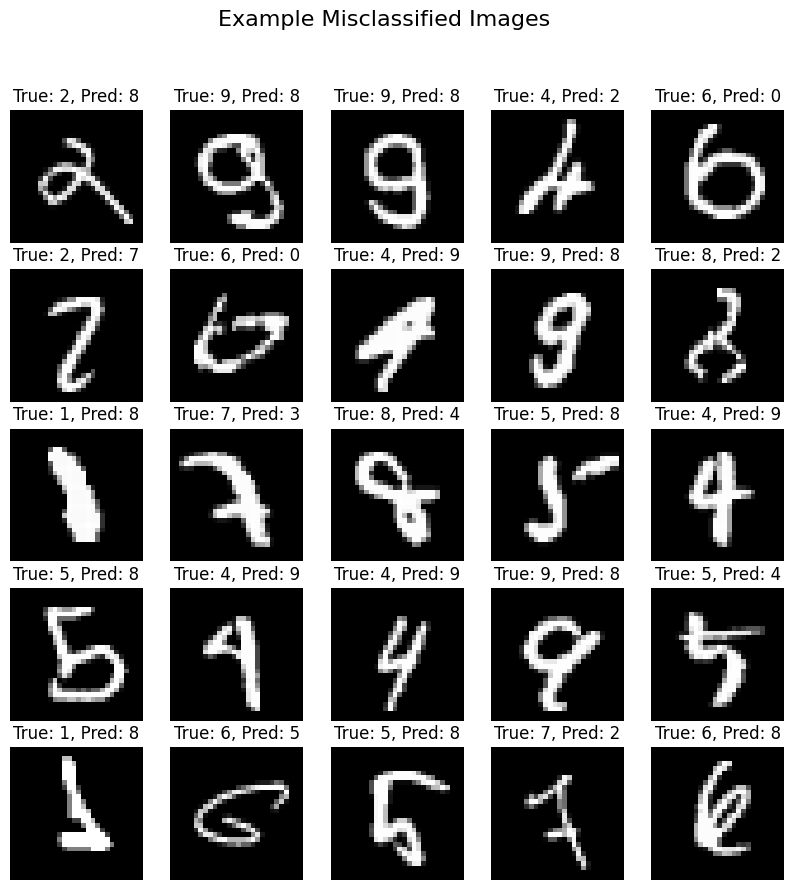

In [23]:
# Identify indices where predictions don't match true labels
misclassified_indices = np.where(predicted_labels != true_labels)[0]

# Plot the first 25 misclassified images
plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_indices[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {true_labels[idx]}, Pred: {predicted_labels[idx]}")
    plt.axis('off')
plt.suptitle("Example Misclassified Images", fontsize=16)
plt.show()

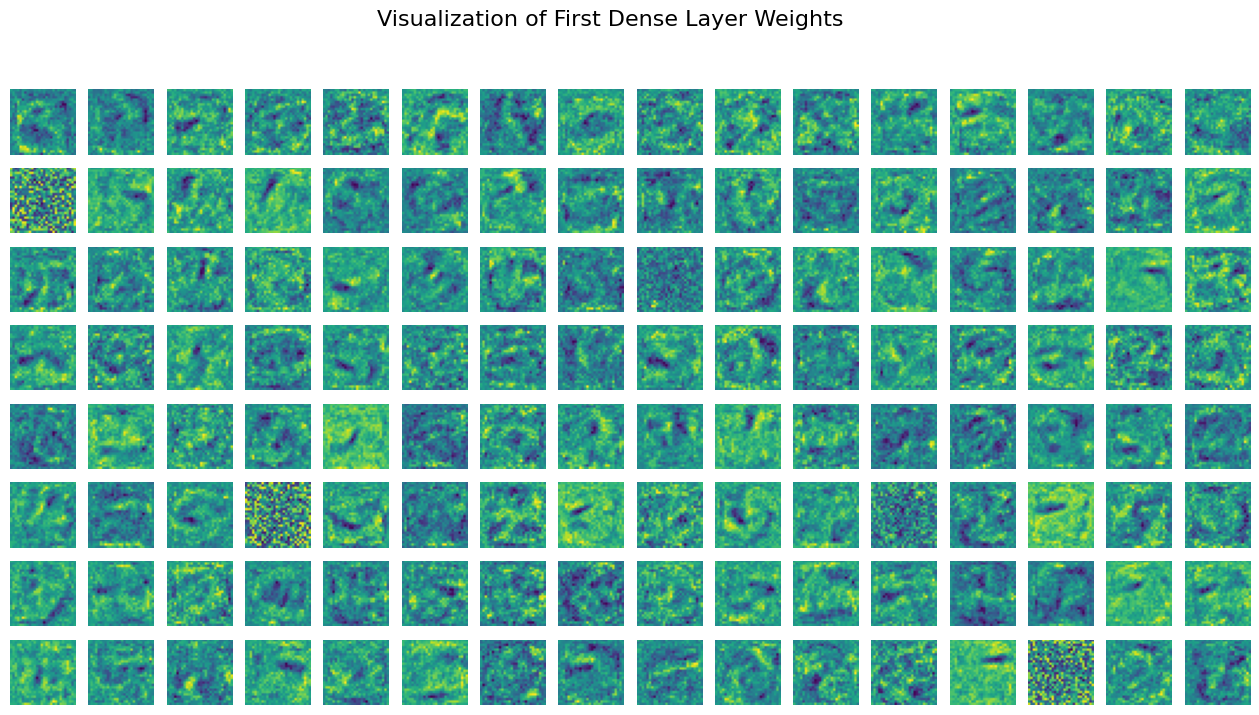

In [24]:
# Retrieve the weights from the first Dense layer (after the Flatten layer)
# Typically, model.layers[1] is the first Dense layer (if your model architecture matches the example)
weights, biases = model.layers[1].get_weights()

# Each column in the weight matrix corresponds to a neuron in the dense layer.
# Reshape each column back to 28x28 for visualization.
num_neurons = weights.shape[1]

# Create a grid to display the weights; here we assume a grid of 8 rows by 16 columns (for up to 128 neurons).
nrows, ncols = 8, 16
plt.figure(figsize=(16, 8))
for i in range(num_neurons):
    plt.subplot(nrows, ncols, i + 1)
    # Reshape the weight vector to 28x28, then plot it using a colormap
    plt.imshow(weights[:, i].reshape(28, 28), cmap='viridis')
    plt.axis('off')
plt.suptitle("Visualization of First Dense Layer Weights", fontsize=16)
plt.show()